# Top-K evaluation of the final model

PR-AUC (0.174) and ROC-AUC (0.734) answer "how good is the ranking overall". F1 answers "how good is the model at one chosen threshold (0.70)". Neither directly answers a more practical question for an inspection-prioritization setting: if only a limited fraction of inspections could be prioritized by predicted risk, how many of the actual future Non-Pass inspections would fall inside that top slice? This notebook doesn't change the model at all, it's evaluation only, using the exact tuned CatBoost model from Prompt 14/15.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

## Rebuild the 15-feature set (unchanged) and the fixed final model

In [2]:
pred = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                    parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)
long = pd.read_csv("../outputs/inspection_level_longitudinal.csv",
                    parse_dates=["inspectionDate"], low_memory=False)
long = long.sort_values(["estId", "inspectionDate"]).reset_index(drop=True)
long["is_non_pass"] = long["inspectionStatus"].isin(["Conditional Pass", "Closed"]).astype(int)

def rolling_window(g, days, prefix):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    total_infr = g["n_infractions"].to_numpy()
    crucial = g["n_crucial"].to_numpy()
    non_pass = g["is_non_pass"].to_numpy()

    cs_infr = np.concatenate([[0], np.cumsum(total_infr)])
    cs_crucial = np.concatenate([[0], np.cumsum(crucial)])
    cs_nonpass = np.concatenate([[0], np.cumsum(non_pass)])

    lower_edge = dates - np.timedelta64(days, "D")
    low_idx = np.searchsorted(dates, lower_edge, side="left")

    idx_arr = np.arange(len(g))
    return pd.DataFrame({
        "orig_index": g["index"],
        f"{prefix}_n_inspections": idx_arr - low_idx,
        f"{prefix}_n_non_pass": cs_nonpass[idx_arr] - cs_nonpass[low_idx],
        f"{prefix}_total_infractions": cs_infr[idx_arr] - cs_infr[low_idx],
        f"{prefix}_crucial_infractions": cs_crucial[idx_arr] - cs_crucial[low_idx],
    })

rolled_730 = long.groupby("estId", group_keys=False).apply(rolling_window, days=730, prefix="prior_730d").set_index("orig_index")
long_feat = long.join(rolled_730)

hist_730 = long_feat[["estId", "inspectionDate", "prior_730d_n_inspections", "prior_730d_n_non_pass",
                       "prior_730d_total_infractions", "prior_730d_crucial_infractions"]]

df = pred.merge(hist_730, on=["estId", "inspectionDate"], how="left")
assert len(df) == len(pred)

BASE = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
        "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]
HIST365 = ["prior_365d_n_inspections", "prior_365d_n_non_pass",
           "prior_365d_total_infractions", "prior_365d_crucial_infractions"]
HIST730 = ["prior_730d_n_inspections", "prior_730d_n_non_pass",
           "prior_730d_total_infractions", "prior_730d_crucial_infractions"]
FEATURES = BASE + HIST365 + HIST730
assert len(FEATURES) == 15

In [3]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

unique_dates = np.sort(df["inspectionDate"].unique())
n_dates = len(unique_dates)
train_cut = unique_dates[int(n_dates * 0.70)]
val_cut = unique_dates[int(n_dates * 0.85)]

train = df[df["inspectionDate"] < train_cut].copy()
test = df[df["inspectionDate"] >= val_cut].copy()

assert len(train) == 45334
assert len(test) == 12692
assert test["inspectionDate"].min() == pd.Timestamp("2026-04-10")
assert test["inspectionDate"].max() == pd.Timestamp("2026-09-08")
print("test set: 12,692 rows,", test["inspectionDate"].min().date(), "to", test["inspectionDate"].max().date())

test set: 12,692 rows, 2026-04-10 to 2026-09-08


In [4]:
X_train, y_train = train[FEATURES], train["target"]
X_test, y_test = test[FEATURES], test["target"]

model = CatBoostClassifier(
    iterations=300, depth=4, learning_rate=0.05, loss_function="Logloss",
    auto_class_weights="Balanced", random_seed=42, verbose=False,
)
model.fit(X_train, y_train)
test_proba = model.predict_proba(X_test)[:, 1]
print("trained, test probabilities generated")

trained, test probabilities generated


## Reproduce the existing test metrics

Just confirming this is the same model/test setup already reported, not a replacement for it.

In [5]:
test_pr_auc = average_precision_score(y_test, test_proba)
test_roc_auc = roc_auc_score(y_test, test_proba)
print("test PR-AUC:", round(test_pr_auc, 4), "(expect ~0.174)")
print("test ROC-AUC:", round(test_roc_auc, 4), "(expect ~0.734)")

test PR-AUC: 0.1742 (expect ~0.174)
test ROC-AUC: 0.7337 (expect ~0.734)


## Ranking test inspections by predicted risk

Top-K works directly from the probability ranking, it doesn't use the 0.70 threshold from Prompt 14/15 at all, that threshold answers a different question (classify at one cutoff) than this one (how good is the top slice of the ranking).

In [6]:
order = np.argsort(-test_proba)
sorted_target = y_test.to_numpy()[order]

n = len(test)
total_non_pass = int(sorted_target.sum())
prevalence = total_non_pass / n
print("test rows:", n, " total Non-Pass:", total_non_pass, " prevalence:", round(prevalence, 4))

assert len(np.unique(order)) == n  # every test row appears in exactly one ranking position

test rows: 12692  total Non-Pass: 954  prevalence: 0.0752


## Top-K metrics

Precision@K = actual Non-Pass in the top K / K. Recall@K = actual Non-Pass in the top K / all actual Non-Pass in test. Lift@K = Precision@K / overall prevalence, how much more concentrated the top slice is than picking inspections at random.

In [7]:
rows = []
for k_pct in [1, 5, 10, 20, 25, 100]:
    k = max(int(round(n * k_pct / 100)), 1)
    selected = sorted_target[:k]
    actual_np = int(selected.sum())
    precision = actual_np / k
    recall = actual_np / total_non_pass
    lift = precision / prevalence
    rows.append({
        "k_percent": k_pct, "n_selected": k, "actual_non_pass_selected": actual_np,
        "precision_at_k": precision, "recall_at_k": recall, "lift_at_k": lift,
    })

result_df = pd.DataFrame(rows)
result_df

,k_percent,n_selected,actual_non_pass_selected,precision_at_k,recall_at_k,lift_at_k
0,1,127,32,0.251969,0.033543,3.352185
1,5,635,156,0.245669,0.163522,3.268380
2,10,1269,267,0.210402,0.279874,2.799183
3,20,2538,444,0.174941,0.465409,2.327411
4,25,3173,520,0.163883,0.545073,2.180294
5,100,12692,954,0.075165,1.000000,1.000000


## Sanity checks

At 100% capacity, selecting everyone should trivially recover the full picture: recall 1.0, lift 1.0, precision equal to the overall prevalence.

In [8]:
full = result_df[result_df["k_percent"] == 100].iloc[0]
assert abs(full["recall_at_k"] - 1.0) < 1e-9
assert abs(full["lift_at_k"] - 1.0) < 1e-9
assert abs(full["precision_at_k"] - prevalence) < 1e-9
print("Recall@100% =", full["recall_at_k"], " Lift@100% =", full["lift_at_k"], " Precision@100% =", full["precision_at_k"])
print("all sanity checks passed")

Recall@100% = 1.0  Lift@100% = 1.0  Precision@100% = 0.07516545855657107
all sanity checks passed


## Comparison against random prioritization

A random slice of the same size would be expected to have precision close to the overall prevalence and lift close to 1, regardless of K, that's the reference every row above should be compared to.

In [9]:
result_df_display = result_df[result_df["k_percent"] != 100].copy()
result_df_display["random_expected_precision"] = prevalence
result_df_display["random_expected_lift"] = 1.0
result_df_display

,k_percent,n_selected,actual_non_pass_selected,precision_at_k,recall_at_k,lift_at_k,random_expected_precision,random_expected_lift
0,1,127,32,0.251969,0.033543,3.352185,0.075165,1.0
1,5,635,156,0.245669,0.163522,3.268380,0.075165,1.0
2,10,1269,267,0.210402,0.279874,2.799183,0.075165,1.0
3,20,2538,444,0.174941,0.465409,2.327411,0.075165,1.0
4,25,3173,520,0.163883,0.545073,2.180294,0.075165,1.0


## Cumulative recall plot

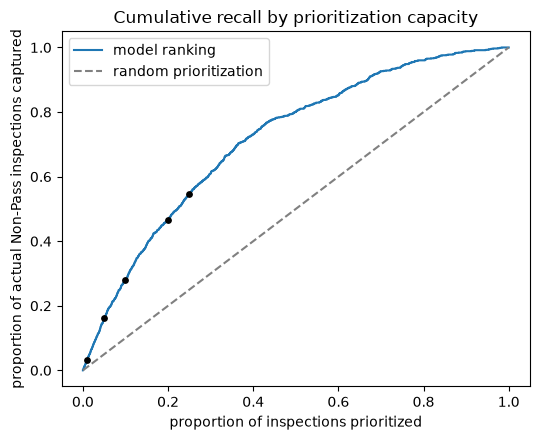

In [10]:
capacities = np.arange(0, 101) / 100
cum_non_pass = np.cumsum(sorted_target)
recall_curve = cum_non_pass / total_non_pass
recall_curve = np.concatenate([[0], recall_curve])
model_x = np.arange(0, n + 1) / n

plt.figure(figsize=(5.5, 4.5))
plt.plot(model_x, recall_curve, label="model ranking")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="random prioritization")
for k_pct in [1, 5, 10, 20, 25]:
    row = result_df[result_df["k_percent"] == k_pct].iloc[0]
    plt.scatter([k_pct / 100], [row["recall_at_k"]], color="black", s=15, zorder=5)
plt.xlabel("proportion of inspections prioritized")
plt.ylabel("proportion of actual Non-Pass inspections captured")
plt.title("Cumulative recall by prioritization capacity")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/top_k_recall_curve.png", dpi=100)
plt.show()

## Save results

In [11]:
result_df.to_csv("../outputs/top_k_results.csv", index=False)
print("saved outputs/top_k_results.csv")

saved outputs/top_k_results.csv


## Why this is different from F1

F1 asks how good the model is at one chosen probability threshold (0.70). Top-K asks a different, more operational question: if only a limited fraction of inspections can be prioritized, how much does ranking by predicted risk concentrate the actual Non-Pass cases into that fraction. For an inspection-prioritization use case, that's arguably the more directly useful question, and it doesn't depend on picking a threshold at all.

## Interpretation

Top 10% of test inspections by predicted risk contains 28.0% of all actual Non-Pass inspections, at 2.8x the concentration random selection would give (precision 21.0% vs. 7.5% overall prevalence). Top 20% captures 46.5% of Non-Pass cases at 2.3x lift, top 25% captures 54.5% at 2.2x lift. Even the top 1% alone (127 inspections) catches 32 actual Non-Pass cases, a precision of 25% and a lift of 3.35x.

This is a moderate-to-strong concentration effect, not the "35-40% at top 10%" benchmark named as a strong-outcome example in the research design, but clearly well above what random prioritization would achieve at every capacity level checked. It helps explain why a PR-AUC around 0.17 can still represent real, usable signal: the overall PR-AUC score is modest because most of the test set is easy, low-risk Pass inspections that don't discriminate the metric much, but the highest-risk slice of the ranking is genuinely enriched for actual Non-Pass cases.

This describes retrospective ranking performance on already-observed outcomes. It does not show that prioritizing inspections this way would prevent future problems or improve real-world food safety, that would require a prospective evaluation this project hasn't run.